# 04 - champion slice analysis

Dissect the archived champion replay by symbol, side, time, regime proxies, and entry context. Goal: identify what helps or hurts before proposing another strategy change.

In [1]:
import json
import sys; sys.path.insert(0, ".")
from _lab import *

best = json.loads(BEST_JSON.read_text(encoding="utf-8"))
symbols = list(best["symbols"])
params = dict(best["params"])
tf = best["tf"]
start, end = best["period"]

result = run_strategy_file(BEST_STRATEGY_FILE, symbols, start, end, params=params, tf=tf, return_curves=True)
curves = result["curves"]
trades = curves["trades"].copy()
trades["entry_time"] = pd.to_datetime(trades["entry_time"], utc=True)
trades["exit_time"] = pd.to_datetime(trades["exit_time"], utc=True)
trades["side"] = trades["direction"].str.lower()
trades["month"] = trades["entry_time"].dt.to_period("M").astype(str)
trades["year"] = trades["entry_time"].dt.year
trades["entry_hour"] = trades["entry_time"].dt.hour
print(len(trades), "trades")
metrics_frame(result)

516 trades


C:\Users\digbi\AppData\Local\Temp\ipykernel_22448\4198021940.py:17: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  trades["month"] = trades["entry_time"].dt.to_period("M").astype(str)


,sharpe,sortino,max_dd,total_return,n_trades,pct_time_in_position,profit_factor
split,,,,,,,
train,2.256844,2.987076,0.086786,0.976731,379,60.425532,1.488818
oos,0.376976,0.435786,0.114798,0.032848,137,67.062044,1.054225


In [2]:
# Add entry context from OHLCV: prior 24h move, realized vol, volume ratio, bar range.
data = load_pair_data(symbols, start, end, tf=tf)
ctx_rows = []
for sym, df in data.items():
    d = df.copy()
    avg_volume = d["volume"].rolling(params["volume_ma"], min_periods=params["volume_ma"]).mean().shift(1)
    d["vol_ratio"] = d["volume"] / avg_volume
    d["prior_24h_ret"] = d["close"].pct_change(6)
    d["prior_3d_ret"] = d["close"].pct_change(18)
    d["realized_vol_7d"] = d["close"].pct_change().rolling(42).std() * np.sqrt(6 * 365)
    d["bar_range_pct"] = (d["high"] - d["low"]) / d["close"]
    d["symbol"] = sym
    ctx_rows.append(d[["symbol", "vol_ratio", "prior_24h_ret", "prior_3d_ret", "realized_vol_7d", "bar_range_pct"]])
ctx = pd.concat(ctx_rows).reset_index().rename(columns={"timestamp": "entry_time"})
tr = trades.merge(ctx, on=["entry_time", "symbol"], how="left")
tr[["symbol", "side", "slice", "entry_time", "return_pct", "pnl_quote", "vol_ratio", "prior_24h_ret", "realized_vol_7d"]].head()

,symbol,side,slice,entry_time,return_pct,pnl_quote,vol_ratio,prior_24h_ret,realized_vol_7d
0,BTCUSDT,long,train,2024-01-08 16:00:00+00:00,-0.002004,-4.864516,3.889411,0.062283,0.566677
1,BTCUSDT,short,train,2024-01-18 20:00:00+00:00,0.043033,118.615923,1.884100,-0.033930,0.541874
2,BTCUSDT,long,train,2024-01-26 12:00:00+00:00,0.024054,58.966907,1.725712,0.040215,0.460426
3,BTCUSDT,long,train,2024-01-29 20:00:00+00:00,-0.000299,-0.739260,0.683080,0.030229,0.421663
4,BTCUSDT,long,train,2024-02-07 20:00:00+00:00,0.002732,6.681501,2.288107,0.028644,0.292584


In [3]:
def slice_table(df, by, min_trades=1):
    out = df.groupby(by).agg(
        n=("return_pct", "size"),
        pnl=("pnl_quote", "sum"),
        avg_ret=("return_pct", "mean"),
        med_ret=("return_pct", "median"),
        win_rate=("return_pct", lambda s: (s > 0).mean()),
        avg_win=("pnl_quote", lambda s: s[s > 0].mean()),
        avg_loss=("pnl_quote", lambda s: s[s <= 0].mean()),
        avg_duration_h=("duration_hours", "mean"),
    )
    out["payoff"] = out["avg_win"].abs() / out["avg_loss"].abs()
    return out[out["n"] >= min_trades].sort_values("pnl", ascending=False)

slice_table(tr, "symbol")

,n,pnl,avg_ret,med_ret,win_rate,avg_win,avg_loss,avg_duration_h,payoff
symbol,,,,,,,,,
SOLUSDT,106,3641.855132,0.007936,0.003932,0.537736,194.048142,-151.405897,34.415094,1.281642
AVAXUSDT,91,3109.986618,0.009069,0.017680,0.582418,213.084401,-215.354911,38.681319,0.989457
ETHUSDT,143,3102.923663,0.004511,-0.003854,0.489510,167.051724,-117.680781,33.790210,1.419533
BTCUSDT,176,738.443455,0.001402,-0.000324,0.488636,106.486593,-93.548928,33.295455,1.138298


In [4]:
slice_table(tr, ["symbol", "side"])

n          pnl   avg_ret   med_ret  win_rate     avg_win  \
symbol   side                                                               
SOLUSDT  short  57  3200.197116  0.012061  0.009828  0.578947  219.655310   
ETHUSDT  short  76  2360.744948  0.006166 -0.000295  0.500000  170.891225   
AVAXUSDT long   35  1915.177345  0.016749  0.022190  0.628571  208.966152   
         short  56  1194.809273  0.004269  0.002941  0.553571  216.007028   
BTCUSDT  short  86  1023.258716  0.002642  0.001348  0.511628  114.354562   
ETHUSDT  long   67   742.178715  0.002634 -0.010695  0.477612  162.492317   
SOLUSDT  long   49   441.658016  0.003137 -0.000580  0.489796  158.838286   
BTCUSDT  long   90  -284.815261  0.000218 -0.001860  0.466667   98.243958   

                  avg_loss  avg_duration_h    payoff  
symbol   side                                         
SOLUSDT  short -168.684504       38.035088  1.302166  
ETHUSDT  short -108.766357       31.894737  1.571177  
AVAXUSDT long  -206.313693       34.971429  1.012856  
         short -220.056344       41.000000  0.981599  
BTCUSDT  short  -95.436715       34.744186  1.198224  
ETHUSDT  long  -127.359298       35.940299  1.275858  
SOLUSDT  long  -134.818434       30.204082  1.178164  
BTCUSDT  long   -91.897115       31.911111  1.069065

In [5]:
slice_table(tr, ["slice", "side"])

n          pnl   avg_ret   med_ret  win_rate     avg_win  \
slice side                                                                
train short  196  7616.571165  0.008737  0.006479  0.561224  163.029833   
      long   183  2309.315649  0.004244  0.002732  0.508197  132.242022   
oos   long    58   504.883166  0.002748 -0.002731  0.465517  201.365426   
      short   79   162.438887 -0.001141 -0.001895  0.455696  209.361909   

               avg_loss  avg_duration_h    payoff  
slice side                                         
train short -119.961750       34.469388  1.359015  
      long  -110.991027       34.185792  1.191466  
oos   long  -159.096236       29.793103  1.265683  
      short -171.502089       39.493671  1.220754

In [6]:
monthly = slice_table(tr, "month")
monthly

,n,pnl,avg_ret,med_ret,win_rate,avg_win,avg_loss,avg_duration_h,payoff
month,,,,,,,,,
2024-08,26,1920.170323,0.016687,0.015087,0.615385,201.448773,-130.301005,39.076923,1.546026
2025-10,24,1522.321752,0.010551,0.010977,0.666667,189.190581,-188.090943,38.666667,1.005846
2024-12,23,1468.055502,0.014384,0.015773,0.695652,143.573300,-118.445327,22.782609,1.212148
2025-11,20,1439.604172,0.009642,0.015042,0.550000,278.675738,-180.647661,37.000000,1.542648
2025-02,21,1187.240621,0.011596,-0.002935,0.476190,365.303003,-224.162674,28.190476,1.629634
2024-04,22,1164.442894,0.015021,0.005106,0.545455,147.204616,-60.201250,29.272727,2.445209
2024-02,16,1073.289687,0.024963,0.019750,0.812500,84.666546,-9.125135,37.000000,9.278388
2024-06,28,950.924966,0.008885,0.010015,0.678571,93.624627,-91.993660,41.285714,1.017729
2025-05,16,595.308905,0.007899,0.007361,0.562500,137.850737,-92.192532,19.000000,1.495248


[saved] notebooks\volume_weighted_breakout\_out\04_champion_slices_monthly.png


WindowsPath('C:/Users/digbi/Projects/research-lab/notebooks/volume_weighted_breakout/_out/04_champion_slices_monthly.png')

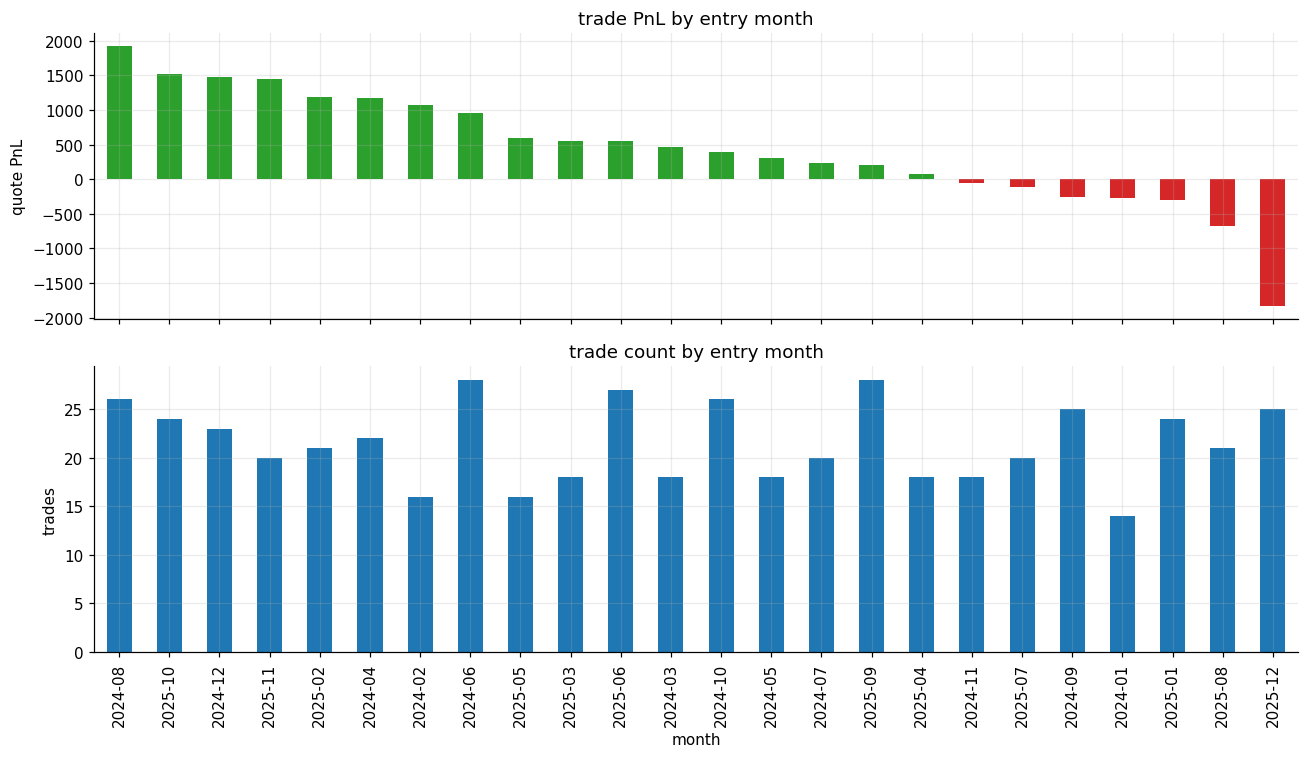

In [7]:
fig, ax = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
monthly["pnl"].plot(kind="bar", ax=ax[0], color=np.where(monthly["pnl"] >= 0, "C2", "C3"))
ax[0].set_title("trade PnL by entry month")
ax[0].set_ylabel("quote PnL")
monthly["n"].plot(kind="bar", ax=ax[1], color="C0")
ax[1].set_title("trade count by entry month")
ax[1].set_ylabel("trades")
show("04_champion_slices_monthly")

In [8]:
# Entry context bins. These are diagnostic, not optimization decisions.
tr["prior_24h_bin"] = pd.qcut(tr["prior_24h_ret"], 5, duplicates="drop")
tr["vol_ratio_bin"] = pd.qcut(tr["vol_ratio"], 5, duplicates="drop")
tr["realized_vol_bin"] = pd.qcut(tr["realized_vol_7d"], 5, duplicates="drop")

display(slice_table(tr.dropna(subset=["prior_24h_bin"]), ["side", "prior_24h_bin"]))
display(slice_table(tr.dropna(subset=["vol_ratio_bin"]), ["side", "vol_ratio_bin"]))
display(slice_table(tr.dropna(subset=["realized_vol_bin"]), ["side", "realized_vol_bin"]))

n          pnl   avg_ret   med_ret  win_rate  \
side  prior_24h_bin                                                        
short (-0.271, -0.0454]    96  4801.226439  0.010738  0.016376  0.656250   
long  (0.0429, 0.121]     100  4165.575993  0.010864  0.014717  0.580000   
short (-0.0454, -0.0246]   99  3225.569484  0.006056 -0.000329  0.484848   
long  (-0.271, -0.0454]     8   942.646714  0.032869  0.036083  0.750000   
short (0.0148, 0.0429]      6    70.882380  0.002928 -0.002044  0.333333   
      (0.0429, 0.121]       3    24.824656  0.001369 -0.003854  0.333333   
long  (-0.0454, -0.0246]    4    -5.146490  0.000352  0.001514  0.500000   
      (-0.0246, 0.0148]    32   -38.382747 -0.000506 -0.005941  0.406250   
short (-0.0246, 0.0148]    71  -343.492908 -0.000419 -0.001895  0.450704   
long  (0.0148, 0.0429]     97 -2250.494653 -0.004108 -0.012757  0.422680   

                             avg_win    avg_loss  avg_duration_h    payoff  
side  prior_24h_bin                                                         
short (-0.271, -0.0454]   193.883059 -224.648675       36.291667  0.863050  
long  (0.0429, 0.121]     180.774914 -150.461167       41.840000  1.201472  
short (-0.0454, -0.0246]  193.787045 -119.141346       42.909091  1.626531  
long  (-0.271, -0.0454]   165.871571  -26.291357       15.500000  6.308977  
short (0.0148, 0.0429]     99.196632  -31.877721        8.666667  3.111786  
      (0.0429, 0.121]     145.157830  -60.166587        5.333333  2.412599  
long  (-0.0454, -0.0246]   27.124452  -29.697697        4.000000  0.913352  
      (-0.0246, 0.0148]    99.598482  -70.166475       17.000000  1.419460  
short (-0.0246, 0.0148]   112.823389 -101.380547       29.239437  1.112870  
long  (0.0148, 0.0429]    119.662707 -127.797601       32.123711  0.936345

n          pnl   avg_ret   med_ret  win_rate  \
side  vol_ratio_bin                                                    
short (1.263, 1.682]   58  4169.553741  0.012923  0.005395  0.568966   
      (1.682, 2.253]   44  3184.356003  0.016506  0.015015  0.636364   
long  (1.682, 2.253]   59  2212.709308  0.009274  0.014698  0.627119   
      (1.263, 1.682]   45  1338.105414  0.007195 -0.002715  0.488889   
short (0.354, 0.92]    62   814.584946  0.002023 -0.006265  0.451613   
      (2.253, 17.121]  52   471.859168  0.003212  0.001854  0.538462   
long  (0.354, 0.92]    42   237.974585  0.002575 -0.012260  0.404762   
      (0.92, 1.263]    44   -37.463658  0.001625 -0.009475  0.454545   
short (0.92, 1.263]    59  -861.343806 -0.002473 -0.002263  0.491525   
long  (2.253, 17.121]  51  -937.126833 -0.002245 -0.000951  0.470588   

                          avg_win    avg_loss  avg_duration_h    payoff  
side  vol_ratio_bin                                                      
short (1.263, 1.682]   203.463146 -101.789204       35.379310  1.998868  
      (1.682, 2.253]   174.976471 -107.186574       35.000000  1.632448  
long  (1.682, 2.253]   134.248426 -125.203747       34.237288  1.072240  
      (1.263, 1.682]   189.865160 -123.431657       34.133333  1.538221  
short (0.354, 0.92]    181.309474 -125.355304       40.064516  1.446365  
      (2.253, 17.121]  135.809969 -138.784165       25.615385  0.978570  
long  (0.354, 0.92]    214.547304 -136.373183       42.380952  1.573237  
      (0.92, 1.263]    135.577389 -114.542143       33.090909  1.183646  
short (0.92, 1.263]    171.632447 -194.622825       41.830508  0.881872  
long  (2.253, 17.121]   93.012390 -117.386081       23.372549  0.792363

n          pnl   avg_ret   med_ret  win_rate  \
side  realized_vol_bin                                                  
short (0.628, 0.79]     51  2465.882718  0.010480  0.010709  0.568627   
      (0.522, 0.628]    56  2319.771621  0.007828  0.000791  0.517857   
long  (0.522, 0.628]    47  2101.321438  0.011817  0.010456  0.510638   
short (0.2, 0.422]      53  1325.597234  0.006318  0.002402  0.566038   
      (0.422, 0.522]    50   906.891618  0.003663  0.003976  0.520000   
long  (0.79, 1.677]     38   884.194506  0.006308 -0.007532  0.473684   
short (0.79, 1.677]     65   760.866861  0.002023 -0.009233  0.492308   
long  (0.2, 0.422]      51   415.768088  0.002989  0.004400  0.529412   
      (0.628, 0.79]     52  -201.994023  0.000225 -0.002556  0.500000   
      (0.422, 0.522]    53  -385.091193 -0.000436 -0.000951  0.471698   

                           avg_win    avg_loss  avg_duration_h    payoff  
side  realized_vol_bin                                                    
short (0.628, 0.79]     186.298048 -133.489122       33.803922  1.395605  
      (0.522, 0.628]    168.684251  -95.261913       31.071429  1.770742  
long  (0.522, 0.628]    205.801866 -123.387972       38.297872  1.667925  
short (0.2, 0.422]       98.844102  -71.292428       32.075472  1.386460  
      (0.422, 0.522]    143.698383 -117.886097       39.520000  1.218960  
long  (0.79, 1.677]     241.395039 -173.045810       41.578947  1.394978  
short (0.79, 1.677]     264.823208 -233.741691       42.092308  1.132974  
long  (0.2, 0.422]       90.087486  -84.024751       25.254902  1.072154  
      (0.628, 0.79]     134.393314 -142.162315       33.769231  0.945351  
      (0.422, 0.522]    100.977232 -103.911500       29.433962  0.971762

In [9]:
# Worst and best trades: look for repeated failure patterns.
cols = ["entry_time", "exit_time", "slice", "symbol", "side", "pnl_quote", "return_pct", "duration_hours", "vol_ratio", "prior_24h_ret", "prior_3d_ret", "realized_vol_7d"]
display(tr[cols].sort_values("pnl_quote").head(20))
display(tr[cols].sort_values("pnl_quote", ascending=False).head(20))

,entry_time,exit_time,slice,symbol,side,pnl_quote,return_pct,duration_hours,vol_ratio,prior_24h_ret,prior_3d_ret,realized_vol_7d
475,2025-02-28 04:00:00+00:00,2025-03-02 16:00:00+00:00,train,AVAXUSDT,short,-852.673853,-0.176247,60.0,1.180575,-0.103501,-0.010797,1.224355
500,2025-09-23 00:00:00+00:00,2025-09-25 08:00:00+00:00,oos,AVAXUSDT,long,-628.726303,-0.112756,56.0,3.106188,0.098638,0.037947,1.105144
420,2025-12-01 04:00:00+00:00,2025-12-02 16:00:00+00:00,oos,SOLUSDT,short,-562.188100,-0.095750,36.0,1.090059,-0.066989,-0.083513,0.791270
404,2025-08-18 04:00:00+00:00,2025-08-22 16:00:00+00:00,oos,SOLUSDT,short,-529.203448,-0.087576,108.0,1.244733,-0.058560,-0.083321,0.939208
512,2025-12-09 16:00:00+00:00,2025-12-11 04:00:00+00:00,oos,AVAXUSDT,long,-471.754097,-0.080455,36.0,2.824444,0.079303,0.099023,0.695301
484,2025-06-05 20:00:00+00:00,2025-06-07 04:00:00+00:00,train,AVAXUSDT,short,-470.973799,-0.095830,32.0,3.592047,-0.067142,-0.114259,0.714445
362,2024-11-01 16:00:00+00:00,2024-11-06 04:00:00+00:00,train,SOLUSDT,short,-440.688878,-0.093853,108.0,1.256788,-0.012744,-0.064848,0.519695
514,2025-12-18 20:00:00+00:00,2025-12-19 16:00:00+00:00,oos,AVAXUSDT,short,-415.409202,-0.075612,20.0,0.845305,-0.035431,-0.073194,0.872229
311,2025-12-01 04:00:00+00:00,2025-12-02 16:00:00+00:00,oos,ETHUSDT,short,-360.767794,-0.061037,36.0,1.239089,-0.055044,-0.053907,0.649721
476,2025-03-10 20:00:00+00:00,2025-03-11 20:00:00+00:00,train,AVAXUSDT,short,-354.450912,-0.075472,24.0,1.723995,-0.094708,-0.192547,1.252607


,entry_time,exit_time,slice,symbol,side,pnl_quote,return_pct,duration_hours,vol_ratio,prior_24h_ret,prior_3d_ret,realized_vol_7d
379,2025-02-28 16:00:00+00:00,2025-03-02 16:00:00+00:00,train,SOLUSDT,long,774.653571,0.163553,48.0,0.754780,0.073394,0.005915,1.339577
510,2025-11-17 20:00:00+00:00,2025-11-21 08:00:00+00:00,oos,AVAXUSDT,short,624.294139,0.091131,84.0,1.442081,-0.040780,-0.039764,0.998707
448,2024-08-03 20:00:00+00:00,2024-08-05 04:00:00+00:00,train,AVAXUSDT,short,577.934844,0.123422,32.0,1.247009,-0.039847,-0.118506,0.733725
203,2024-05-17 16:00:00+00:00,2024-05-20 20:00:00+00:00,train,ETHUSDT,long,563.283852,0.177566,76.0,0.914256,0.047801,0.066025,0.453090
386,2025-04-03 00:00:00+00:00,2025-04-06 20:00:00+00:00,train,SOLUSDT,short,536.344063,0.090532,92.0,1.238180,-0.036137,-0.038150,0.979139
378,2025-02-24 04:00:00+00:00,2025-02-24 20:00:00+00:00,train,SOLUSDT,short,522.684084,0.114124,16.0,1.996557,-0.068630,-0.084263,0.872351
260,2025-02-02 20:00:00+00:00,2025-02-03 00:00:00+00:00,train,ETHUSDT,short,518.270894,0.118381,4.0,3.046969,-0.079204,-0.116315,0.802373
346,2024-08-04 16:00:00+00:00,2024-08-05 04:00:00+00:00,train,SOLUSDT,short,508.546147,0.117043,12.0,2.989191,0.011259,-0.125739,1.064713
418,2025-11-13 20:00:00+00:00,2025-11-17 20:00:00+00:00,oos,SOLUSDT,short,503.250067,0.070466,96.0,1.448543,-0.056863,-0.135195,0.956286
274,2025-05-08 04:00:00+00:00,2025-05-08 16:00:00+00:00,train,ETHUSDT,long,455.726898,0.094926,12.0,1.591214,0.049098,0.055689,0.545993


In [10]:
# Quick what-if diagnostics: remove one slice at a time from the trade ledger.
# This is not a real portfolio rebalance, but it shows which trade families dominate PnL.
base_pnl = tr["pnl_quote"].sum()
rows = []
for sym in symbols:
    rows.append({"removed": sym, "pnl_without": base_pnl - tr.loc[tr["symbol"] == sym, "pnl_quote"].sum()})
for side in sorted(tr["side"].unique()):
    rows.append({"removed": side, "pnl_without": base_pnl - tr.loc[tr["side"] == side, "pnl_quote"].sum()})
pd.DataFrame(rows).assign(delta_vs_base=lambda d: d["pnl_without"] - base_pnl).sort_values("delta_vs_base", ascending=False)

,removed,pnl_without,delta_vs_base
0,BTCUSDT,9854.765413,-738.443455
4,long,7779.010052,-2814.198816
1,ETHUSDT,7490.285205,-3102.923663
3,AVAXUSDT,7483.222249,-3109.986618
2,SOLUSDT,6951.353736,-3641.855132
5,short,2814.198816,-7779.010052
